## Covarianza


In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [19]:
def get_multivariate_gaussian(mu, sigma):
    x = np.linspace(-4, 4, 100)
    y = np.linspace(-4, 4, 100)
    X, Y = np.meshgrid(x, y)
    pos = np.dstack((X, Y))

    k = mu.shape[0]
    diff = pos - mu

    inv_sigma = np.linalg.inv(sigma)
    det_sigma = np.linalg.det(sigma)

    # Calculamos (x-mu)^T * Sigma^-1 * (x-mu) eficientemente sobre toda la grilla
    exponent = np.einsum("...k,kl,...l->...", diff, inv_sigma, diff)

    norm_const = 1.0 / np.sqrt(((2 * np.pi) ** k) * det_sigma)
    Z = norm_const * np.exp(-0.5 * exponent)

    return X, Y, Z


def plot_gaussian(X, Y, Z):
    fig = plt.figure(figsize=(12, 5))

    ax1 = fig.add_subplot(121)
    contour = ax1.contourf(X, Y, Z, cmap="viridis")
    fig.colorbar(contour, ax=ax1)
    ax1.set_title(f"Contour Plot")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_aspect("equal")

    ax2 = fig.add_subplot(122, projection="3d")
    surface = ax2.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none")
    fig.colorbar(surface, ax=ax2, shrink=0.5, aspect=5)
    ax2.set_title("3D Surface Plot")
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    ax2.set_zlabel("Probability Density")

    plt.tight_layout()
    plt.show()

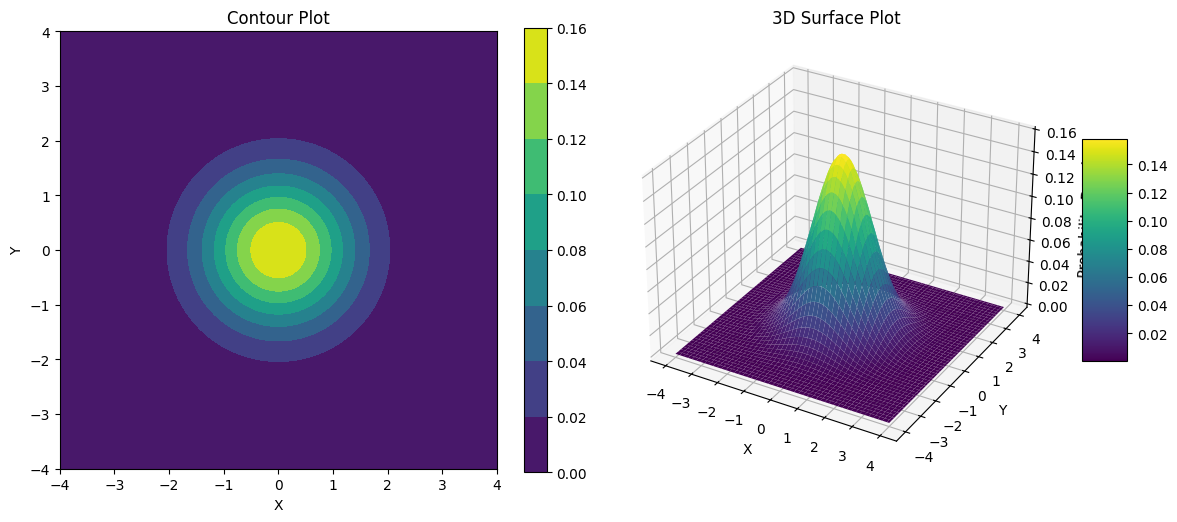

In [20]:
mu1 = np.array([0, 0])
sigma1 = np.array([[1.0, 0.0], [0.0, 1.0]])

X1, Y1, Z1 = get_multivariate_gaussian(mu1, sigma1)
plot_gaussian(X1, Y1, Z1)

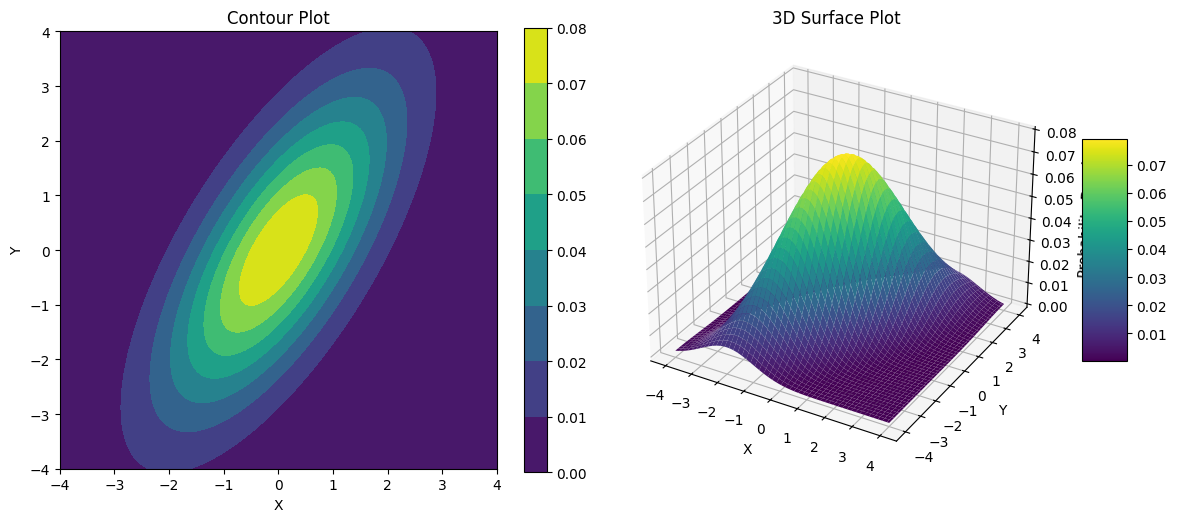

In [22]:
mu2 = np.array([0, 0])
sigma2 = np.array([[2.0, 2.0], [2.0, 4.0]])

X2, Y2, Z2 = get_multivariate_gaussian(mu2, sigma2)
plot_gaussian(X2, Y2, Z2)

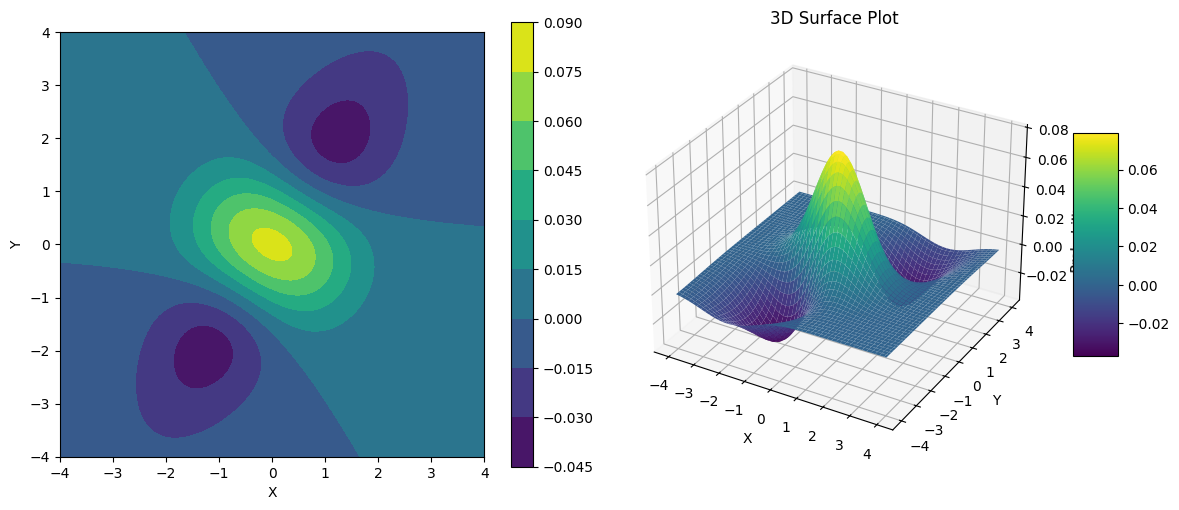

In [18]:
# Restar las dos distribuciones
Z_diff = Z1 - Z2

# Plotear usando la función
plot_gaussian(X1, Y1, Z_diff)